#**GDG TASK 3**

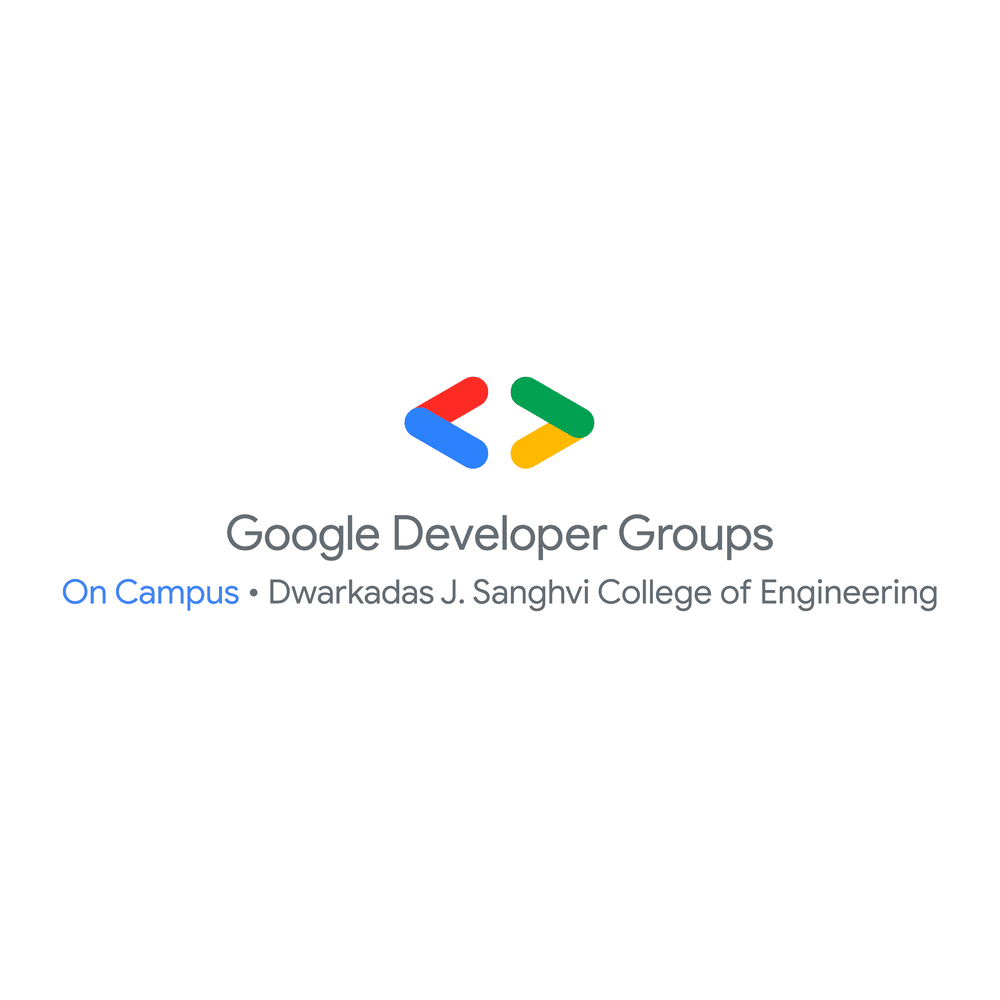

**Unsupervised Learning**

Clustering is an unsupervised learning technique used to group similar data points together. It's widely used in various applications like customer segmentation, anomaly detection, and more. In this task, we'll explore different clustering algorithms and visualize their results.

We will work with the **Samsung Human Activity Recognition dataset**. The data comes from the accelerometers and gyros of Samsung mobile phones, the type of activity of a person with a phone in his pocket is also known - whether he walked, stood, lay, sat or walked up or down the stairs.

We imagine that the type of activity is unknown to us (unlabelled), and we will try to cluster people purely on the basis of available features.

The dataset that will be used can be found here - [DATA](https://drive.google.com/drive/folders/1YiphBhq_SAN5JvCFrorv3pXIvQ22Jtat)

# Importing and Installing all the necessary libaries

In [ ]:
!pip install yellowbrick -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, MeanShift, SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from yellowbrick.cluster import KElbowVisualizer


from IPython.display import Image,display
from ipywidgets import interact
import os

import warnings
warnings.filterwarnings("ignore")

# Data Loading

Mention the path of dataset, 4 paths for the 4 different txt files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### datasets link :- https://drive.google.com/drive/folders/19nsd8MvooWVsVzkNWxGtbMJheR7kzERt?usp=sharing

In [ ]:
# Mention the path in the strings below
samsung_train_path = '/content/drive/MyDrive/Colab_Notebooks/datasets/samsung_train.txt'
samsung_train_labels_path = '/content/drive/MyDrive/Colab_Notebooks/datasets/samsung_train_labels.txt'
samsung_test_path = '/content/drive/MyDrive/Colab_Notebooks/datasets/samsung_test.txt'
samsung_test_labels_path = '/content/drive/MyDrive/Colab_Notebooks/datasets/samsung_test_labels.txt'

This time we will be using np.loadtxt() for reading our data. Code for the same has been given (do not modify), but we expect you to understand the working of it.

Ref.: https://www.geeksforgeeks.org/numpy-loadtxt-in-python/

In [ ]:
# DO NOT MODIFY
X_train = np.loadtxt(samsung_train_path)
y_train = np.loadtxt(samsung_train_labels_path)#.astype(#fillhere#)

X_test = np.loadtxt(samsung_test_path)
y_test = np.loadtxt(samsung_test_labels_path)#.astype(#fillhere#)

Just to confirm that your data has been loaded properly, execute the below cell. You won't receive any error if everything is correct.

NOTE: If you get an Assertion error, then you probably did something wrong above.

In [ ]:
# Checking dimensions
assert(X_train.shape == (7352, 561) and y_train.shape == (7352,))
assert(X_test.shape == (2947, 561) and y_test.shape == (2947,))

# **Pre-processing**

For clustering, we do not need a target vector, so we'll work with the combination of training and test samples. Merge *X_train* with *X_test*, and *y_train* with *y_test*.

Hint:
1. Merge X_train and X_test into X {use [np.vstack()](https://numpy.org/doc/stable/reference/generated/numpy.vstack.html)}
2. Merge y_train and y_test into y {use [np.hstack()](https://numpy.org/doc/stable/reference/generated/numpy.hstack.html)}

In [ ]:
# code

# Merging X_train and X_test via np.vstack() :
X = np.vstack((X_train, X_test))

# Merging y_train and y_test via np.hstack() :
y = np.hstack((y_train, y_test))

Using numpy, print the unique values of the labels of the target class (i.e. "y").

Ref.: https://www.geeksforgeeks.org/python-numpy-np-unique-method/

In [ ]:
# code here
# Printing unique values of the labels y :
np.unique(y)

Store the size (or number) of unique values of the labels of the target class (i.e. "y") in a variable named n_classes.

In [ ]:
# code
# Number of unique values of the labels of y :
n_classes = len(np.unique(y))
print(n_classes)

In [ ]:
activities = [
    "walking",
    "going up the stairs",
    "going down the stairs",
    "sitting",
    "standing",
    "lying down"
]

Here the 6 labels (or classes) correspond to:
- 1 - walking
- 2 - going up the stairs
- 3 - going down the stairs
- 4 - sitting
- 5 - standing
- 6 - lying down

So we wish to create 6 clusters where each cluster can represent one of the above activities.

Scale the sample (i.e. X) using [`StandardScaler()`](https://www.digitalocean.com/community/tutorials/standardscaler-function-in-python)

In [ ]:
# call library
# initialize an instance of StandardScaler()
scaler = StandardScaler()
#code
# use the above instance to fit_transform "X" and assign it into a new variable "X_scaled"
X_scaled = scaler.fit_transform(X)

# **Dimensionality Reduction using PCA**

Ref.: https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [ ]:
# Import PCA from sklearn.decomposition
from sklearn.decomposition import PCA

Reduce the number of dimensions using PCA,

Hints:
1. Initialise instance of PCA and set *n_components* to 0.9 and *random_state* to 17.
2. Fit X_scaled over the PCA instance created
3. Transform X_scaled over the fitted PCA instance and store it in a variable named X_pca.

Theory: https://www.analyticsvidhya.com/blog/2022/07/principal-component-analysis-beginner-friendly/ and https://en.wikipedia.org/wiki/Principal_component_analysis

Theory + Implementation.: https://youtu.be/OFyyWcw2cyM (Jump to timestamp - 13:50 for PCA implementaion)

In [ ]:
# code here
pca = PCA(n_components=0.9, random_state=17)
pca.fit(X_scaled)
X_pca = pca.transform(X_scaled)

Let's check the shape of X_pca.

In [ ]:
# code here
X_pca.shape
# Should print (10299, 65) if everything is correct.

Shape of X was (10299, 561) i.e 561 dimensions

Shape of X_pca is (10299, 65) i.e. 65 dimenisons

Hence we have successfully reduced dimensions using PCA.

# K-Means Clustering (Partition-Based Clustering)

K-means clustering is an essential partitioning algorithm used to categorize a dataset into 'k' distinct, non-overlapping clusters. Each data point is assigned to the cluster with the nearest mean or centroid, symbolizing the cluster's center. The primary goal of the algorithm is to minimize the sum of squared distances between data points and their respective cluster centroids.

For an in-depth exploration of K-means clustering, you can refer to this comprehensive article on Analytics Vidhya: [Comprehensive Guide to K-means Clustering](https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/).

For a deeper understanding of the mathematical underpinnings of K-means clustering, Wikipedia is a valuable resource. You can explore the Wikipedia page on K-means clustering for a detailed description: [K-means Clustering Wikipedia](https://en.wikipedia.org/wiki/K-means_clustering). This will help you grasp the mathematical intricacies of the algorithm and its applications in machine learning.

### 2 Dimensional Visualization

In [ ]:
## Perform K-Means clustering with interactive widget
def kmeans_clustering(num_clusters):
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', edgecolors='k')
    plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('K-Means Clustering')
    plt.legend()
    plt.show()

low = 2
high = 6
scale = 1

interact(kmeans_clustering, num_clusters=(low,high,scale))

### 3 Dimensional Visualization

In [ ]:
## Perform K-Means clustering with interactive widget
def kmeans_3d_clustering(num_clusters):
    kmeans_3d = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans_3d_labels = kmeans_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=kmeans_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Kmeans Clustering (3D)')
    plt.show()

interact(kmeans_3d_clustering, num_clusters=(2, 6, 1))

### Elbow Point

The "elbow point" is a concept often used in the context of K-means clustering to help determine the optimal number of clusters (k) for a given dataset. It is a graphical method that can assist data analysts and machine learning practitioners in finding an appropriate value for k when applying K-means clustering.

The rationale behind the elbow point method is that as you increase the number of clusters (k), the sum of squared distances will generally decrease because data points will be closer to their respective cluster centroids. However, beyond a certain point, subdividing the data into more clusters doesn't provide significant improvements in reducing the sum of squared distances. The elbow point represents that optimal trade-off between the number of clusters and the compactness of each cluster.

It's important to note that the elbow point method is a heuristic and not a foolproof method for determining the ideal k value. In some cases, the elbow point may not be very pronounced, making it challenging to choose the best k. Additionally, the choice of k should also consider domain knowledge and the specific goals of your analysis.

In [ ]:
print('Elbow Method to determine the number of clusters to be formed:')

Elbow_M = KElbowVisualizer(KMeans(), k=(2, 10))
Elbow_M.fit(X_pca)
Elbow_M.show()

Similar to classification and regression metrics, we have some [clustering metrics](https://scikit-learn.org/stable/modules/classes.html#clustering-metrics) to evaluate performance.

We wll explore one of them: [adjusted_rand_index (ARI)](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html)

In [ ]:
from sklearn.metrics.cluster import adjusted_rand_score
kmeans = KMeans(n_clusters=6, random_state=42)
kmeans_labels = kmeans.fit_predict(X_pca)
# code to compute ARI for our KMeans clusters :
ari = adjusted_rand_score(y, kmeans_labels)
print(ari)

# Agglomerative Clustering

It is a hierarchical clustering algorithm used in unsupervised machine learning and data analysis. It is a "bottom-up" or "agglomerative" approach to clustering, where individual data points are initially treated as their own clusters and then progressively merged into larger clusters based on a similarity or distance metric. The result is a tree-like structure called a dendrogram that represents the hierarchical relationships between clusters.

As always, You can find more detailed information about hierarchical clustering, including agglomerative clustering, in the Wikipedia article on "Hierarchical clustering" at the following link: [Hierarchical Clustering Wikipedia](https://en.wikipedia.org/wiki/Hierarchical_clustering). This is the best resource for hierarchical clustering and it is advisable to go through it twice if possible! :)

### 2 Dimensional Visualization

In [ ]:
# Perform Agglomerative clustering with interactive widget
def agglomerative_clustering(num_clusters):
  agglomerative = AgglomerativeClustering(n_clusters=num_clusters)
  agglomerative_labels = agglomerative.fit_predict(X_pca)

  plt.figure(figsize=(8, 6))
  plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agglomerative_labels, cmap='viridis', edgecolors='k')
  plt.xlabel('Feature 1 (Standardized)')
  plt.ylabel('Feature 2 (Standardized)')
  plt.title('Agglomerative Clustering')
  plt.legend()
  plt.show()

interact(agglomerative_clustering, num_clusters=(2,6,1)) # Fill here

### 3 Dimensional Visualization

In [ ]:
# Perform Agglomerative clustering with interactive widget
def agglomerative_3d_clustering(num_clusters):
    agglomerative_3d = AgglomerativeClustering(n_clusters=num_clusters)
    agglomerative_3d_labels = agglomerative_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=agglomerative_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('agglomerative Clustering (3D)')
    plt.show()

interact(agglomerative_3d_clustering, num_clusters=(2,6,1)) # Fill here

In [ ]:
#go through the library of clusteval in order to draw and make dendrograms in your task!

# DBSCAN Clustering

DBSCAN, which stands for Density-Based Spatial Clustering of Applications with Noise, is a popular density-based clustering algorithm in unsupervised machine learning. It is particularly useful for discovering clusters of arbitrary shapes in datasets with varying levels of data density. DBSCAN is known for its ability to handle noise and outliers effectively.

As always, You can find additional information about how DBSCAN clustering works in the following article on Analytics Vidhya:

[How DBSCAN Clustering Works](https://www.analyticsvidhya.com/blog/2020/09/how-dbscan-clustering-works/#:~:text=DBSCAN%20is%20a%20density%2Dbased,points%20into%20a%20single%20cluster.)

This article provides a detailed explanation of DBSCAN, including its underlying concepts, the role of epsilon (ε) and minimum points (MinPts), and practical examples of how to use DBSCAN for clustering. It's a valuable resource for gaining a deeper understanding of the algorithm with Wikipedia as the side resource.

### 2 Dimensional Visualization

In [ ]:
# Perform DBSCAN clustering with interactive widget
def dbscan_clustering(eps, min_samples):
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_labels = dbscan.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('DBSCAN Clustering')
    plt.legend()
    plt.show()

interact(dbscan_clustering, eps=(0.1,3,1), min_samples=(2,6,1)) # Fill here

### 3 Dimensional Visualization

In [ ]:
# Perform DBSCAN clustering with interactive widget
def dbscan_3d_clustering(eps, min_samples):
    dbscan_3d = DBSCAN(eps=eps, min_samples=min_samples)
    dbscan_3d_labels = dbscan_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=dbscan_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('DBSCAN Clustering (3D)')
    plt.show()
interact(dbscan_3d_clustering, eps=(0.1, 3, 1), min_samples=(2, 6, 1)) # Fill here

# Mean Shift Clustering

It is a density-based clustering algorithm used in unsupervised machine learning and data analysis. Similar to DBSCAN, Mean Shift is capable of discovering clusters with arbitrary shapes and sizes in a dataset. It is particularly useful for applications where the number of clusters is not known in advance and when clusters have varying densities.

For more hands-on information about the Mean Shift clustering algorithm, you can refer to this tutorial on Analytics India Magazine:

[Hands-On Tutorial on Mean Shift Clustering Algorithm](https://analyticsindiamag.com/hands-on-tutorial-on-mean-shift-clustering-algorithm/)

This tutorial provides practical insights into how to implement and use Mean Shift clustering, making it a valuable resource for those looking to apply this clustering technique to real-world data analysis and machine learning tasks especially in the sector of Image Segmentation.

### 2 Dimensional Visualization

In [ ]:
# Perform Mean Shift clustering with interactive widget
def meanshift_clustering(n_band):
    mean_shift = MeanShift(bandwidth=n_band)
    mean_shift_labels = mean_shift.fit_predict(X_pca)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mean_shift_labels, cmap='viridis', edgecolors='k')
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.title('Mean Shift Clustering')
    plt.legend()
    plt.show()

interact(meanshift_clustering, n_band=(2,6,1)) # Fill here

### 3 Dimensional Visualization

In [ ]:
# Perform Mean Shift clustering with interactive widget
def meanshift_clustering(n_band):
    meanshift_3d = MeanShift(bandwidth=n_band)
    meanshift_3d_labels = meanshift_3d.fit_predict(X_pca)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=meanshift_3d_labels, cmap='viridis', edgecolors='k')
    ax.set_xlabel('Feature 1 (Standardized)')
    ax.set_ylabel('Feature 2 (Standardized)')
    ax.set_zlabel('Feature 3 (Standardized)')
    ax.set_title('Mean Shift Clustering (3D)')
    plt.show()

interact(meanshift_clustering, n_band=(2,6,1))

***Congratulations! You have explored various clustering algorithms. Each algorithm has its own advantages and use cases. Remember, choosing the right algorithm and the right number of clusters is crucial. Feel free to experiment with different datasets and parameters to gain a better understanding.***

# **Compulsory**

You can research and create a short blog on the topic of **Spectral Clustering Algortihm and Divisive Clustering**.



Spectral Clusterig Algorithm : Spectral clustering is a graph-based clustering algorithm that groups data by leveraging the eigenstructure of a similarity graph and not just simply based on euclidian distance.

Divisive Clustering : It works exactly opposite to agglomerative clustering. In divisive clustering, we start by taking one cluster constituting of all data points and iteratively based on euclidian distance start dividing the reference cluster into smaller clusters.

we will be exploring another ML Models like Decision Tree, Random Forest and Naive Bayes. We will also learn hyperparameter tuning using ensemble techniques (Bagging & Boosting) and Decision Tree Pruning.

**This Task has various theory questions to be answered here and there. Don't miss out on those, as they will make you'll conceptually stronger, and give a better understanding.**

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

# Decision Tree Classifier

* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

### separate datset for this task.

Load the titanic dataset in a pandas dataframe (download dataset from https://www.kaggle.com/c/titanic/data and store it in the "Synapse" folder initially created for the interview tasks) Note that you have to download the train and test csv files seperately

<b>Read the train.csv using pandas and show the dataframe</b>

In [ ]:
#code here
df = pd.read_csv('/content/drive/MyDrive/Colab_Notebooks/Synapse/train.csv')

### Visualizing hidden Details

* print the name column of the data
* notice that the word after the first comma encapsulates the title of the person (Mr., Mrs, etc)
* extract the title using regular expression (help given below in the code)
* store the title in a new column in the dataframe. Name the column : Title

In [ ]:
print(df['Name'])

In [ ]:
# try researching about regex
# extracting the title using regular expression (help given below in the code) :
df["Title"] = df["Name"].str.extract(r',\s*([A-Za-z]+)\.')
print(df['Age'])


```
# This is formatted as code
```

### Removing unnecessary columns
*   The columns PassengerId and Ticket play no logical role in being related to the survival of a passenger. Hence we will remove them.
*   We will also remove the Name column as we have done feature extraction and obtained titles instead. (test set might have extra titles which are not in the train set. Think about how we would consider them. This however doesn't affect task 1's objective)

In [ ]:
#write code here (PassengerId, Ticket, Name)
df.drop(['PassengerId', 'Ticket', 'Name'], axis=1, inplace=True)

### Nan analysis
*   write code to find the percentage of Nans in each column and visualize it in a tabular format
*   remove any column having more than 50% Nans as they would be of no use

In [ ]:
# likho code and tree null values properly

In [ ]:
df.isnull().mean()*100

In [ ]:
# drop cabin
df.drop('Cabin', axis=1, inplace=True)

### Adding features to the dataset
*   Read the kaggle link (titanic dataset) provided above and see what the two columns SibSP and Parch signify
*   Using that create a new column called **Family_members**
*   Fill it with the sum of SibSP and Parch

In [ ]:
#write code here
df['Family_members'] = df['SibSp'] + df['Parch']

**Pre Processing**

In [ ]:
#ab ana chahiye after task 2

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
# Encoding Sex,Embarked and Title cols :
df = pd.get_dummies(df, columns=['Sex', 'Title'], drop_first=True)

In [ ]:
df.isnull().sum()
df

In [ ]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

In [ ]:
# Converting true to 1 and fasle to 0 throughout the dataframe :
df = df.replace({True: 1, False: 0})

In [ ]:
df

In [ ]:
# Using KNN imputer for missing values :
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
df = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

extract the y label (survived) from the dataframe and store it in a new variable and remove y from original dataframe (x,y split)

In [ ]:
#write code here
y = df['Survived']
X = df.drop('Survived', axis=1)

In [ ]:
X

<b>Split the data into train and test. (do a split in the ratio 70:30)</b>

In [ ]:
#write code here
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

<b>Now that you have the entire preprocessed and split data, implement the decision tree algorithm from sklearn and fit it to this dataset</b> <br>

In [ ]:
#write code here
from sklearn.tree import DecisionTreeClassifier
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)

<b>Print the Model Accuracy</b>

In [ ]:
#write code here
from sklearn.metrics import accuracy_score
y_pred = tree_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

## Explain: Give a Real life Example where Decision Tree Classifier can be used.

Ans: Banking - Loan Approval System

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

In [ ]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)

In [ ]:
#complete the code below to create an image of the decision tree
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz(tree_clf, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file


## Explain: What is your understanding of the charts you made above?
Ans: Exact breakdown of metrics of each iteration as each node of the decision tree breaks down into two subtrees.

# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [ ]:
# Write a code to implement naive bayes algorithm, and give the accuracy for the same
# Naive Bayes Algorithm :
from sklearn.naive_bayes import GaussianNB
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_train)

In [ ]:
# Accuracy
y_pred = nb_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

## Explain: What is the difference between Decision Tree Classifier and Naive Bayes algorithm?

Ans:
Decision Tree : Rule based algorithm that splits data using a sequence of if-else statements.

Naive Bayes : A probabilistic algorithm that is used to classify entities based on Bayes Theorem.


## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [ ]:
#write code for random forest
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier()
rf_clf.fit(X_train, y_train)

In [ ]:
# Accuracy
y_pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

## Explain: Under what condition will Random Forest and Decision Trees have the same accuracy?

Ans: When random forest contains only one tree it is nothing but a decision tree.

## Extra - BaggingClassifier

In [ ]:
#write a code to implement BaggingClassifier
from sklearn.ensemble import BaggingClassifier
bag_clf = BaggingClassifier()
bag_clf.fit(X_train, y_train)

In [ ]:
# Accuracy
y_pred = bag_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

In [ ]:
# Fine tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

## Explain: What is the difference between Random Forest and Bagging Classifier

Ans:
Bagging - It is quite generic in nature that is, it can use any classifier for ensembling.

Random Forest - It is also an ensemble technique but only designed for decision trees.


### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [ ]:
#write code here
from sklearn.ensemble import AdaBoostClassifier
ada_clf = AdaBoostClassifier()
ada_clf.fit(X_train, y_train)

In [ ]:
# Accuracy
y_pred = ada_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

## Explain: What is the difference between Bagging and Boosting?

Ans:

Bagging - All models are trained parallely and independently with each model having equal contribution.

Boosting - Models are trained sequentially and models have different contributions.

### 3. Pruning Techniques

https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107

In [ ]:
#write code here
clf = DecisionTreeClassifier(random_state=42)
path = clf.cost_complexity_pruning_path(X_train, y_train)

ccp_alphas = path.ccp_alphas[:-1]

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = []

for alpha in ccp_alphas:
    tree = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(tree, X_train, y_train, cv=5)
    cv_scores.append(scores.mean())

In [ ]:
best_alpha = ccp_alphas[np.argmax(cv_scores)]
print("Best alpha:", best_alpha)

In [ ]:
# Find the best alpha(plot graph)

In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique

In [ ]:
pruned_tree = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=best_alpha
)
pruned_tree.fit(X_train, y_train)

In [ ]:
# Accuracy
y_pred = pruned_tree.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

In [ ]:
!pip install graphviz
from sklearn.tree import export_graphviz
pruned_decision_tree = export_graphviz(pruned_tree,out_file='pruned_tree.dot',feature_names=X_train.columns,max_depth=2,filled=True)
!dot -Tpng pruned_tree.dot -o pruned_tree.png # to convert the file

<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

## Explain: After studying these techniques, analyse which method gives you the best accuracy and choose it as your most optimal model.

Ans: Adaboost classifier


# **Compulsory Task**

### **XGBoost and AdaBoost Classifier and Regressor: A Comparative Overview**

XGBoost is an optimized  implementation of gradient boosting. It uses gradient descent to fit residual errors. It also can be pruned and regularized effectively. It is fast and usable for large datasets.

AdaBoost sequentially trains weak learners. It increases the weight of misclassified samples. It is much more efficient on smaller datasets. Pruning and regularization is weak if done here.

Loss functions :    
XGBoost Classifier : Logarthimic  
XGBoost Regressor : Mean squared error
AdaBoost Classifier : Exponential  
AadBoost Regressor : Mean squared error